# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members

* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu


# Notebook 06, External Validation and Generalization Study


## Notebook purpose

This notebook runs the **external validation study** for the skin lesion classification project.

In `04_ablation_study.ipynb`, the project trained three CNN backbones on the ISIC 2019 training split and evaluated cumulative augmentation stages on the ISIC 2019 validation split. The purpose of this notebook is different. Here, the trained models from Notebook 04 are evaluated on an **external dataset**, MILK10K, to test whether augmentation gains persist under cross-dataset distribution shift.

A few design choices are important:

1. **MILK10K is external-only.**  
   No MILK10K images are used for model fitting, checkpoint selection, or hyperparameter tuning in this notebook.
2. **The MILK10K training partition is used as the external evaluation set.**  
   In this project, the partition named "training" is used only because it is the portion with available ground-truth lesion diagnoses.
3. **Lesion-level evaluation is the primary analysis.**  
   Each MILK10K lesion has two associated images. Predictions are generated at the image level, then aggregated to the lesion level by averaging class probabilities across the two images. Because the diagnosis is defined at the lesion level, lesion-level metrics are treated as primary, while image-level metrics are retained as supplementary diagnostics.
4. **The initial external comparison focuses on the final cumulative augmentation stage.**  
   The first pass in this notebook compares the three backbones at `phase1_plus_2_plus_3_plus_4`, then later expands to the full 12-model external ablation ladder.
5. **Label-space compatibility is handled explicitly.**  
   MILK10K contains several diagnosis categories that are not part of the 8-class ISIC 2019 training label space. For the initial image-only external evaluation, Notebook 06 restricts analysis to lesions whose MILK diagnoses map directly onto the ISIC 8-class target set.


## Execution structure

This notebook supports two execution modes.

### 1. Smoke-test mode

Smoke mode is used to verify that the external evaluation pipeline works end to end on a small lesion-stratified subset of the MILK10K external dataset.

This mode is intended to test:

* raw-file loading
* label harmonization
* image-path construction
* lesion-level aggregation
* checkpoint loading
* metric computation
* confusion-matrix generation
* output saving

### 2. Full mode

Full mode runs the complete MILK10K external validation study.

Because HPC access windows can be limited, this notebook is designed to support **one-backbone-at-a-time execution** without changing the scientific design. A typical full run can therefore be organized as:

* Session 1, ResNet-50 external evaluation
* Session 2, EfficientNet-B0 external evaluation
* Session 3, DenseNet-121 external evaluation
* Final aggregation session, combine results and generate summary plots

### Planned external-evaluation order

This notebook is intentionally staged in two steps.

**Step A, initial external comparison**

* Evaluate the three `phase1_plus_2_plus_3_plus_4` checkpoints on MILK10K
* Compare lesion-level macro AUC and balanced accuracy
* Compute the ISIC to MILK10K generalization gap for each backbone

**Step B, full external ablation**

* Evaluate all four augmentation stages for each backbone
* Replicate the cumulative ablation ladder externally
* Test whether augmentation narrows the cross-dataset generalization gap


In [1]:
# ============================================================
# NOTEBOOK 06 CONFIGURATION
# ============================================================

SMOKE_MODE = True

# Run the three final-stage models first, then expand later
INITIAL_EXTERNAL_ONLY = True
PRIMARY_STAGE = "phase1_plus_2_plus_3_plus_4"

ABLATION_STAGES = [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4",
]

BACKBONES = [
    "resnet50",
    "efficientnet_b0",
    "densenet121",
]

# For short HPC sessions, this list can be reduced to one backbone
BACKBONES_TO_RUN = BACKBONES.copy()

# Smoke-mode sampling is done at the lesion level, not the image level
SMOKE_LESIONS_PER_SUPPORTED_CLASS = 40
SMOKE_RANDOM_STATE = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

SAVE_PREDICTIONS = True
SAVE_FIGURES = True
SAVE_REPORTS = True
SAVE_SUMMARY_TABLES = True

EXPERIMENT_SEED = 42


## Imports and project-root setup

This section imports the core Python, PyTorch, and evaluation libraries used throughout the notebook, then resolves the project root so the notebook can consistently find the shared `scripts/` directory and prior project outputs.

Unlike Notebook 04, this notebook is **inference-first**, not training-first. As a result, the imports emphasize:

* data loading
* checkpoint loading
* metric computation
* confusion matrices
* prediction aggregation
* figure generation

Only the backbone model builders are imported from `scripts/`. The augmentation helper modules are not needed for external inference because evaluation uses the fixed validation transform rather than train-time augmentation.


In [2]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)


In [3]:
# ============================================================
# RESOLVE PROJECT ROOT AND IMPORT SHARED MODEL BUILDERS
# ============================================================

# Resolve the project root, not just the current notebook directory
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
SCRIPTS = ROOT / "scripts"

if not SCRIPTS.exists():
    raise FileNotFoundError(f"Expected scripts directory at: {SCRIPTS}")

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

# Import only the backbone builders needed for checkpoint reconstruction
from resnet50_baseline import build_resnet50
from efficientnet_b0_baseline import build_efficientnet_b0
from densenet121_baseline import build_densenet121

MODEL_BUILDERS = {
    "resnet50": build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121": build_densenet121,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CWD:     ", cwd)
print("ROOT:    ", ROOT)
print("SCRIPTS: ", SCRIPTS)
print("DEVICE:  ", DEVICE)


CWD:      /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/Code
ROOT:     /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
SCRIPTS:  /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/scripts
DEVICE:   cuda


## Save experiment configuration and set seeds

This section creates the output directories for Notebook 06, saves the active notebook configuration, and fixes the random seed for reproducibility.

Because this notebook supports both smoke mode and backbone-specific HPC execution, the saved configuration records the **overall external-evaluation setup** rather than a single run result.


In [4]:
# ============================================================
# OUTPUT DIRECTORIES, CONFIG SAVE, AND REPRODUCIBILITY
# ============================================================

OUT_ROOT = ROOT / "outputs"

CONFIG_DIR = OUT_ROOT / "configs" / "06_external_evaluation"
FIG_DIR = OUT_ROOT / "figures" / "06_external_evaluation"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"
CKPT_DIR = OUT_ROOT / "checkpoints"
REPORT_DIR = OUT_ROOT / "reports" / "06_external_evaluation"

for d in [CONFIG_DIR, FIG_DIR, METRIC_DIR, PRED_DIR, CKPT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG = {
    "notebook": "06_external_evaluation",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "initial_external_only": INITIAL_EXTERNAL_ONLY,
    "primary_stage": PRIMARY_STAGE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "backbones_to_run": BACKBONES_TO_RUN,
    "smoke_lesions_per_supported_class": SMOKE_LESIONS_PER_SUPPORTED_CLASS,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "save_predictions": SAVE_PREDICTIONS,
    "save_figures": SAVE_FIGURES,
    "save_reports": SAVE_REPORTS,
    "save_summary_tables": SAVE_SUMMARY_TABLES,
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

def seed_everything(seed: int):
    # Fix Python, NumPy, and PyTorch randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(EXPERIMENT_SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(EXPERIMENT_SEED)

print("Saved config to:", config_path)
print("Global seed set.")
print("DataLoader generator seeded.")


Saved config to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/06_external_evaluation/smoke_config.json
Global seed set.
DataLoader generator seeded.


## Locate and load raw MILK10K source tables

This notebook loads the raw MILK10K **training** tables directly.

The required external-evaluation inputs are:

* `MILK10k_Training_GroundTruth.csv`
* `MILK10k_Training_Metadata.csv`
* `MILK10k_Training_Supplement.csv`
* the corresponding image directory containing lesion folders and image files

The image directory is expected to be organized as:

* one folder per `lesion_id`
* two image files per lesion folder
* image files named from `isic_id`

This section resolves those raw-file locations and loads the source tables into memory.


In [5]:
# ============================================================
# FIND MILK10K FILES USING THE PROJECT'S ACTUAL DIRECTORY LAYOUT
# ============================================================

def first_existing_path(path_candidates):
    # Return the first path that exists, or None if none exist
    for p in path_candidates:
        if p.exists():
            return p
    return None

# Base MILK directories used elsewhere in the project
MILK_BASE_CANDIDATES = [
    ROOT / "DATA" / "milk10k",
    ROOT / "DATA" / "raw" / "milk10k",
]

MILK_BASE = first_existing_path(MILK_BASE_CANDIDATES)

if MILK_BASE is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K base directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in MILK_BASE_CANDIDATES)
    )

# Training CSV files live under DATA/milk10k/train
MILK_TRAIN_DIR_CANDIDATES = [
    ROOT / "DATA" / "milk10k" / "train",
    MILK_BASE / "train",
]

MILK_TRAIN_DIR = first_existing_path(MILK_TRAIN_DIR_CANDIDATES)

if MILK_TRAIN_DIR is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K training directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in MILK_TRAIN_DIR_CANDIDATES)
    )

GT_PATH = MILK_TRAIN_DIR / "MILK10k_Training_GroundTruth.csv"
META_PATH = MILK_TRAIN_DIR / "MILK10k_Training_Metadata.csv"
SUPP_PATH = MILK_TRAIN_DIR / "MILK10k_Training_Supplement.csv"

required_paths = [GT_PATH, META_PATH, SUPP_PATH]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required MILK10K source files:\n" + "\n".join(missing_paths)
    )

# Images may appear with one extra nested folder depending on zip extraction
TRAIN_IMAGE_ROOT_CANDIDATES = [
    MILK_TRAIN_DIR / "images" / "MILK10k_Training_Input",
    MILK_TRAIN_DIR / "images" / "MILK10k_Training_Input" / "MILK10k_Training_Input",
    MILK_TRAIN_DIR / "images",
]

TRAIN_IMAGE_ROOT = first_existing_path(TRAIN_IMAGE_ROOT_CANDIDATES)

if TRAIN_IMAGE_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the MILK10K training image directory.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in TRAIN_IMAGE_ROOT_CANDIDATES)
    )

milk_gt_df = pd.read_csv(GT_PATH)
milk_meta_df = pd.read_csv(META_PATH)
milk_supp_df = pd.read_csv(SUPP_PATH)

print("MILK_BASE:", MILK_BASE)
print("MILK_TRAIN_DIR:", MILK_TRAIN_DIR)
print("GT_PATH:", GT_PATH)
print("META_PATH:", META_PATH)
print("SUPP_PATH:", SUPP_PATH)
print("TRAIN_IMAGE_ROOT:", TRAIN_IMAGE_ROOT)
print()

print("milk_gt_df shape:", milk_gt_df.shape)
print("milk_meta_df shape:", milk_meta_df.shape)
print("milk_supp_df shape:", milk_supp_df.shape)


MILK_BASE: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k
MILK_TRAIN_DIR: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train
GT_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_GroundTruth.csv
META_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_Metadata.csv
SUPP_PATH: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/MILK10k_Training_Supplement.csv
TRAIN_IMAGE_ROOT: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/milk10k/train/images/MILK10k_Training_Input

milk_gt_df shape: (5240, 12)
milk_meta_df shape: (10480, 17)
milk_

In [6]:
# Quick audit of the image root
print("Sample lesion folders:")
for p in sorted(TRAIN_IMAGE_ROOT.iterdir())[:5]:
    print(" -", p.name)

first_lesion = next((p for p in sorted(TRAIN_IMAGE_ROOT.iterdir()) if p.is_dir()), None)
if first_lesion is not None:
    print("\nFirst lesion folder:", first_lesion.name)
    print("Contained files:")
    for f in sorted(first_lesion.iterdir()):
        print("   ", f.name)


Sample lesion folders:
 - IL_0000652
 - IL_0003176
 - IL_0004688
 - IL_0005081
 - IL_0006177

First lesion folder: IL_0000652
Contained files:
    ISIC_4671410.jpg
    ISIC_8149219.jpg


## Harmonize MILK10K labels and construct external evaluation tables

MILK10K and ISIC 2019 do not use exactly the same diagnosis labels.

The image-only models trained in Notebook 04 were fit on the following 8-class ISIC label space:

* AK
* BCC
* BKL
* DF
* MEL
* NV
* SCC
* VASC

MILK10K includes several additional categories that are not part of that output space. For the initial image-only external evaluation, Notebook 06 therefore performs explicit label harmonization:

### Supported MILK to ISIC mappings

* `AKIEC` → `AK`
* `BCC` → `BCC`
* `BKL` → `BKL`
* `DF` → `DF`
* `MEL` → `MEL`
* `NV` → `NV`
* `SCCKA` → `SCC`
* `VASC` → `VASC`

### Initial unsupported categories

* `BEN_OTH`
* `INF`
* `MAL_OTH`

These unsupported lesions are excluded from the initial image-only external comparison because the trained CNN checkpoints do not have output nodes for those diagnoses.

This section builds two linked dataframes:

1. **Lesion-level table**  
   One row per lesion, with the harmonized diagnosis label
2. **Image-level table**  
   Two rows per lesion, one for each image, with the corresponding image path and harmonized lesion label


In [7]:
# ============================================================
# LABEL HARMONIZATION AND IMAGE-PATH CONSTRUCTION
# ============================================================

# Notebook 04 used the sorted ISIC labels below
CANONICAL_LABELS = ["AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"]
CANONICAL_LABEL_TO_IDX = {label: idx for idx, label in enumerate(CANONICAL_LABELS)}
IDX_TO_CANONICAL_LABEL = {idx: label for label, idx in CANONICAL_LABEL_TO_IDX.items()}

# MILK ground-truth columns
MILK_DIAG_COLS = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC",
]

MILK_TO_ISIC_LABEL = {
    "AKIEC": "AK",
    "BCC": "BCC",
    "BKL": "BKL",
    "DF": "DF",
    "MEL": "MEL",
    "NV": "NV",
    "SCCKA": "SCC",
    "VASC": "VASC",
}

# Basic guardrail, each lesion should have exactly one positive diagnosis row
milk_gt_df = milk_gt_df.copy()
milk_gt_df["diagnosis_row_sum"] = milk_gt_df[MILK_DIAG_COLS].sum(axis=1)

if not np.allclose(milk_gt_df["diagnosis_row_sum"].values, 1.0):
    raise ValueError(
        "MILK ground-truth rows are not one-hot encoded as expected."
    )

# Extract the raw MILK diagnosis label and map into the ISIC 8-class space
milk_gt_df["milk_label_raw"] = milk_gt_df[MILK_DIAG_COLS].idxmax(axis=1)
milk_gt_df["label"] = milk_gt_df["milk_label_raw"].map(MILK_TO_ISIC_LABEL)
milk_gt_df["is_supported_label"] = milk_gt_df["label"].isin(CANONICAL_LABELS)

# Split lesion-level tables into supported and excluded subsets
milk_supported_lesions_df = milk_gt_df[milk_gt_df["is_supported_label"]].copy()
milk_excluded_lesions_df = milk_gt_df[~milk_gt_df["is_supported_label"]].copy()

milk_supported_lesions_df["label_idx"] = (
    milk_supported_lesions_df["label"].map(CANONICAL_LABEL_TO_IDX)
)

# Merge lesion labels onto the image metadata
milk_images_df = milk_meta_df.merge(
    milk_gt_df[["lesion_id", "milk_label_raw", "label", "is_supported_label"]],
    on="lesion_id",
    how="left",
    validate="many_to_one",
)

# Build image filenames and absolute image paths
milk_images_df["isic_id"] = milk_images_df["isic_id"].astype(str).str.strip()
milk_images_df["image_filename"] = milk_images_df["isic_id"] + ".jpg"
milk_images_df["image_path"] = milk_images_df.apply(
    lambda row: str(TRAIN_IMAGE_ROOT / row["lesion_id"] / row["image_filename"]),
    axis=1,
)

# Quick image-existence check
milk_images_df["image_exists"] = milk_images_df["image_path"].map(
    lambda p: Path(p).exists()
)

# Restrict to lesions supported by the current 8-class image-only models
milk_supported_images_df = milk_images_df[milk_images_df["is_supported_label"]].copy()
milk_supported_images_df["label_idx"] = (
    milk_supported_images_df["label"].map(CANONICAL_LABEL_TO_IDX)
)

# Sort for reproducible downstream evaluation
milk_supported_lesions_df = (
    milk_supported_lesions_df
    .sort_values(["label", "lesion_id"])
    .reset_index(drop=True)
)

milk_supported_images_df = (
    milk_supported_images_df
    .sort_values(["lesion_id", "image_type", "isic_id"])
    .reset_index(drop=True)
)

print("Canonical labels:", CANONICAL_LABELS)
print("Supported lesions:", len(milk_supported_lesions_df))
print("Excluded lesions:", len(milk_excluded_lesions_df))
print("Supported images:", len(milk_supported_images_df))
print()

print("Excluded MILK labels:")
print(milk_excluded_lesions_df["milk_label_raw"].value_counts().sort_index())
print()

print("Supported mapped labels:")
print(milk_supported_lesions_df["label"].value_counts().sort_index())
print()

print("Image-path existence check:")
print(milk_supported_images_df["image_exists"].value_counts(dropna=False))


Canonical labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Supported lesions: 5137
Excluded lesions: 103
Supported images: 10274

Excluded MILK labels:
milk_label_raw
BEN_OTH    44
INF        50
MAL_OTH     9
Name: count, dtype: int64

Supported mapped labels:
label
AK       303
BCC     2522
BKL      544
DF        52
MEL      450
NV       746
SCC      473
VASC      47
Name: count, dtype: int64

Image-path existence check:
image_exists
True    10274
Name: count, dtype: int64


## Smoke-mode lesion sampling and final external evaluation table

If `SMOKE_MODE = True`, the notebook should reduce the external evaluation set at the **lesion level**, then keep both images for every sampled lesion.

This is important. The external evaluation target is lesion diagnosis, so the smoke subset must preserve the two-image structure for each selected lesion rather than sampling individual images independently.

The output of this section is the dataframe that the rest of Notebook 06 will use:

* `milk_eval_lesions_df`, one row per lesion in the active run
* `milk_eval_df`, two rows per lesion in the active run, one per image


In [8]:
# ============================================================
# BUILD THE ACTIVE EXTERNAL EVALUATION SUBSET
# ============================================================

def stratified_lesion_smoke_subset(lesion_df, lesions_per_class=40, random_state=42):
    # Sample lesions within each supported class
    sampled_parts = []

    for label, group in lesion_df.groupby("label", sort=True):
        n_take = min(len(group), lesions_per_class)
        sampled_group = group.sample(n=n_take, random_state=random_state)
        sampled_parts.append(sampled_group)

    out_df = pd.concat(sampled_parts, axis=0)
    out_df = out_df.sort_values(["label", "lesion_id"]).reset_index(drop=True)
    return out_df

if SMOKE_MODE:
    milk_eval_lesions_df = stratified_lesion_smoke_subset(
        milk_supported_lesions_df,
        lesions_per_class=SMOKE_LESIONS_PER_SUPPORTED_CLASS,
        random_state=SMOKE_RANDOM_STATE,
    )
else:
    milk_eval_lesions_df = milk_supported_lesions_df.copy()

milk_eval_df = milk_supported_images_df[
    milk_supported_images_df["lesion_id"].isin(milk_eval_lesions_df["lesion_id"])
].copy()

milk_eval_df = milk_eval_df.sort_values(
    ["lesion_id", "image_type", "isic_id"]
).reset_index(drop=True)

print("SMOKE_MODE:", SMOKE_MODE)
print("Evaluation lesions:", len(milk_eval_lesions_df))
print("Evaluation images:", len(milk_eval_df))
print()

print("Evaluation lesion class counts:")
print(milk_eval_lesions_df["label"].value_counts().sort_index())


SMOKE_MODE: True
Evaluation lesions: 320
Evaluation images: 640

Evaluation lesion class counts:
label
AK      40
BCC     40
BKL     40
DF      40
MEL     40
NV      40
SCC     40
VASC    40
Name: count, dtype: int64


## External-data audit

Before loading checkpoints, the notebook should verify that the external evaluation dataframe looks structurally correct.

The key checks are:

* every supported lesion has exactly two images
* image paths resolve correctly
* lesion counts and image counts agree with expectations
* the supported-class distribution is visible before inference begins

This section is intentionally simple and report-friendly.


Images per lesion distribution:
2    320
Name: count, dtype: int64

Missing image paths in active evaluation set: 0

Image types in active evaluation set:
image_type
clinical: close-up    320
dermoscopic           320
Name: count, dtype: int64



,lesion_id,isic_id,image_type,milk_label_raw,label,image_path
0,IL_0005081,ISIC_5667730,clinical: close-up,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,IL_0005081,ISIC_5186409,dermoscopic,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,IL_0076383,ISIC_1889858,clinical: close-up,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,IL_0076383,ISIC_3175755,dermoscopic,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,IL_0097757,ISIC_1140407,clinical: close-up,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
5,IL_0097757,ISIC_5350161,dermoscopic,BKL,BKL,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
6,IL_0106759,ISIC_2076601,clinical: close-up,DF,DF,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
7,IL_0106759,ISIC_6558326,dermoscopic,DF,DF,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
8,IL_0142779,ISIC_4783176,clinical: close-up,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
9,IL_0142779,ISIC_0881081,dermoscopic,SCCKA,SCC,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


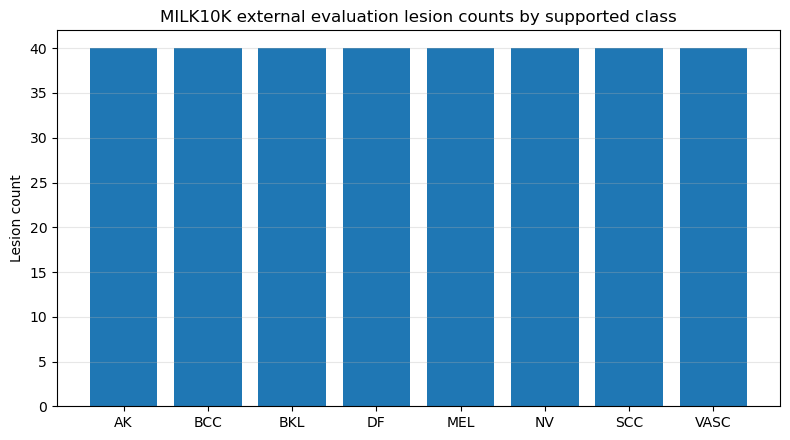

In [9]:
# ============================================================
# QUICK AUDIT OF THE ACTIVE EXTERNAL EVALUATION TABLE
# ============================================================

images_per_lesion = milk_eval_df.groupby("lesion_id").size().sort_values()
missing_image_paths = (~milk_eval_df["image_exists"]).sum()

print("Images per lesion distribution:")
print(images_per_lesion.value_counts().sort_index())
print()

print("Missing image paths in active evaluation set:", int(missing_image_paths))
print()

print("Image types in active evaluation set:")
print(milk_eval_df["image_type"].value_counts().sort_index())
print()

display(
    milk_eval_df[
        ["lesion_id", "isic_id", "image_type", "milk_label_raw", "label", "image_path"]
    ].head(10)
)

# Simple lesion-count bar chart
lesion_count_plot = (
    milk_eval_lesions_df["label"]
    .value_counts()
    .reindex(CANONICAL_LABELS)
)

plt.figure(figsize=(8, 4.5))
plt.bar(lesion_count_plot.index, lesion_count_plot.values)
plt.title("MILK10K external evaluation lesion counts by supported class")
plt.ylabel("Lesion count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        FIG_DIR / ("milk_supported_class_counts_smoke.png" if SMOKE_MODE else "milk_supported_class_counts_full.png"),
        dpi=200,
        bbox_inches="tight",
    )

plt.show()


## Build the external evaluation dataset and fixed inference transform

The MILK10K evaluation dataframe is now ready for model inference.

This section creates the dataset and dataloader objects used during external evaluation. A few design choices matter here:

1. **Inference uses a fixed evaluation transform.**  
   Unlike Notebook 04 training, no augmentation is applied during MILK10K external evaluation. Images are resized and normalized using the same ImageNet normalization scheme used during validation in earlier notebooks.
2. **The dataset remains image-level, while evaluation remains lesion-level.**  
   Each dataset row corresponds to one image, but lesion-level metrics will later be computed by aggregating the two image-level probability vectors belonging to the same lesion.
3. **Metadata needed for later aggregation is returned with each sample.**  
   The dataset returns not only the image tensor and label index, but also lesion ID, image ID, image type, and path. This keeps the inference outputs traceable and simplifies lesion-level aggregation later in the notebook.


In [10]:
# ============================================================
# FIXED EXTERNAL-EVALUATION TRANSFORM
# ============================================================

# ImageNet normalization used in the earlier CNN notebooks
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_eval_transform(image_size=224):
    # Fixed transform for validation and external inference
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

eval_transform = get_eval_transform(image_size=IMAGE_SIZE)

print("Evaluation transform ready.")
print("IMAGE_SIZE:", IMAGE_SIZE)


Evaluation transform ready.
IMAGE_SIZE: 224


## Define the MILK10K external-evaluation dataset

This custom dataset reads rows from `milk_eval_df` and returns a dictionary for each image.

Returning a dictionary, instead of only `(x, y)`, keeps the dataloader flexible and makes downstream result-saving much easier. During external evaluation, this extra metadata is useful for:

* exporting image-level prediction tables
* grouping back to the lesion level
* auditing disagreements between the dermoscopic and clinical image for the same lesion
* tracing errors back to specific files if needed


In [11]:
# ============================================================
# MILK10K EXTERNAL DATASET
# ============================================================

class MilkExternalDataset(Dataset):
    def __init__(self, df, transform=None):
        # Store a clean copy for deterministic behavior
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Pull one image row
        row = self.df.iloc[idx]

        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        sample = {
            "image": image,
            "label_idx": int(row["label_idx"]),
            "label": row["label"],
            "milk_label_raw": row["milk_label_raw"],
            "lesion_id": row["lesion_id"],
            "isic_id": row["isic_id"],
            "image_type": row["image_type"],
            "image_path": str(image_path),
        }
        return sample


## Instantiate the active MILK10K dataset and dataloader

This section builds the active dataloader from `milk_eval_df`.

In smoke mode, the dataloader should contain the balanced lesion-stratified subset created earlier. In full mode, it should contain the full supported MILK10K external evaluation set.

At this point, the notebook is still not running any model inference. The goal here is only to confirm that the dataloader works and that its structure matches the expected external-evaluation design.


In [12]:
# ============================================================
# DATASET AND DATALOADER FOR THE ACTIVE EXTERNAL SET
# ============================================================

milk_eval_dataset = MilkExternalDataset(
    df=milk_eval_df,
    transform=eval_transform,
)

milk_eval_loader = DataLoader(
    milk_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Keep deterministic order for prediction export
    num_workers=NUM_WORKERS,
    generator=loader_generator,
)

print("milk_eval_dataset size:", len(milk_eval_dataset))
print("milk_eval_loader batches:", len(milk_eval_loader))
print("BATCH_SIZE:", BATCH_SIZE)


milk_eval_dataset size: 640
milk_eval_loader batches: 20
BATCH_SIZE: 32


## Quick dataset smoke check

Before loading checkpoints, the notebook should verify that the external dataset and dataloader return the expected structure.

This is a simple but useful checkpoint. If this section fails, the problem is still in the data layer rather than the model-loading layer.


In [13]:
# ============================================================
# QUICK DATASET / DATALOADER CHECK
# ============================================================

first_sample = milk_eval_dataset[0]

print("Single-sample keys:")
print(list(first_sample.keys()))
print()

print("Single-sample metadata:")
print("lesion_id:     ", first_sample["lesion_id"])
print("isic_id:       ", first_sample["isic_id"])
print("image_type:    ", first_sample["image_type"])
print("label:         ", first_sample["label"])
print("label_idx:     ", first_sample["label_idx"])
print("image tensor:  ", tuple(first_sample["image"].shape))

first_batch = next(iter(milk_eval_loader))

print()
print("Batch keys:")
print(list(first_batch.keys()))
print()

print("Batch tensor shape:", tuple(first_batch["image"].shape))
print("Batch label shape:", tuple(first_batch["label_idx"].shape))
print("First few lesion IDs:", list(first_batch["lesion_id"][:5]))


Single-sample keys:
['image', 'label_idx', 'label', 'milk_label_raw', 'lesion_id', 'isic_id', 'image_type', 'image_path']

Single-sample metadata:
lesion_id:      IL_0005081
isic_id:        ISIC_5667730
image_type:     clinical: close-up
label:          SCC
label_idx:      6
image tensor:   (3, 224, 224)

Batch keys:
['image', 'label_idx', 'label', 'milk_label_raw', 'lesion_id', 'isic_id', 'image_type', 'image_path']

Batch tensor shape: (32, 3, 224, 224)
Batch label shape: (32,)
First few lesion IDs: ['IL_0005081', 'IL_0005081', 'IL_0076383', 'IL_0076383', 'IL_0097757']


## Locate internal results from Notebook 04

Notebook 06 needs access to the internal validation results produced earlier in the project.

These results are used for two purposes:

1. **comparison**, to place MILK10K external performance beside the corresponding ISIC validation performance
2. **generalization gap computation**, where the gap is defined as:

$$
\Delta\_{\text{gen}} = \mathrm{BACC}\_{\text{ISIC val}} - \mathrm{BACC}\_{\text{MILK10K}}
$$

For the first external pass, the notebook focuses on the three `phase1_plus_2_plus_3_plus_4` checkpoints. Later, once the full external ladder is run, the same comparison logic will expand to all four stages for each backbone.


In [14]:
# ============================================================
# LOCATE NOTEBOOK 04 INTERNAL COMPARISON OUTPUTS
# ============================================================

ABLAT04_METRIC_CANDIDATES = [
    METRIC_DIR / "ablation_full_comparison.csv",
    METRIC_DIR / "04_ablation_full_comparison.csv",
    METRIC_DIR / "04_ablation_study_full_comparison.csv",
    METRIC_DIR / "ablation_comparison.csv",
]

ABLAT04_METRIC_PATH = first_existing_path(ABLAT04_METRIC_CANDIDATES)

if ABLAT04_METRIC_PATH is None:
    print("WARNING: Could not find the Notebook 04 comparison CSV.")
    print("Checked:")
    for p in ABLAT04_METRIC_CANDIDATES:
        print(" -", p)
    ablat04_df = None
else:
    ablat04_df = pd.read_csv(ABLAT04_METRIC_PATH)
    print("Found Notebook 04 comparison CSV:")
    print(ABLAT04_METRIC_PATH)
    print()
    print("ablat04_df shape:", ablat04_df.shape)
    display(ablat04_df.head())


Found Notebook 04 comparison CSV:
/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_full_comparison.csv

ablat04_df shape: (12, 22)


,backbone,stage,epochs_requested,combined_train_size,val_size,use_cutmix,best_epoch,best_val_loss,best_val_balanced_accuracy,best_val_macro_auc,...,auc_BKL,auc_DF,auc_MEL,auc_NV,auc_SCC,auc_VASC,history_path,pred_path,report_path,checkpoint_path
0,resnet50,baseline,5,21531,3800,False,4,0.859695,0.742629,0.957866,...,0.926637,0.993351,0.918068,0.942791,0.964253,0.998433,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,resnet50,phase1_plus_2,5,43062,3800,False,3,0.679673,0.778907,0.965711,...,0.938429,0.994052,0.916901,0.949907,0.972902,0.998538,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,5,64593,3800,False,5,0.724410,0.793573,0.970311,...,0.946708,0.991646,0.937703,0.955633,0.971286,0.997090,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,resnet50,phase1_plus_2_plus_3_plus_4,5,86124,3800,True,5,0.612439,0.810875,0.967936,...,0.951101,0.975263,0.935472,0.960415,0.970485,0.998972,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,efficientnet_b0,baseline,5,21531,3800,False,4,0.724661,0.775391,0.957333,...,0.932644,0.972628,0.903400,0.942355,0.968923,0.999182,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


## Define checkpoint discovery and robust loading utilities

Checkpoint loading is the first place where project notebooks often get a little temperamental.

Rather than assuming a single exact checkpoint filename or a single exact saved-key structure, this notebook uses a more defensive loading approach. The helper functions below do three things:

1. locate likely checkpoint files by backbone and stage
2. inspect the saved object structure
3. rebuild the correct backbone model and load the state dictionary

This allows Notebook 06 to remain stable even if Notebook 04 used slightly different checkpoint names across runs.


In [15]:
# ============================================================
# CHECKPOINT DISCOVERY HELPERS
# ============================================================

def checkpoint_candidates_for(backbone, stage):
    # Common naming patterns used in project outputs
    return [
        CKPT_DIR / f"{backbone}_{stage}_best.pt",
        CKPT_DIR / f"{backbone}_{stage}.pt",
        CKPT_DIR / f"best_{backbone}_{stage}.pt",
        CKPT_DIR / f"{stage}_{backbone}_best.pt",
    ]

def find_checkpoint_path(backbone, stage):
    # Return the first matching checkpoint path
    candidates = checkpoint_candidates_for(backbone, stage)

    for p in candidates:
        if p.exists():
            return p

    # Fall back to a broader search if needed
    pattern_hits = sorted(CKPT_DIR.glob(f"*{backbone}*{stage}*.pt"))
    if pattern_hits:
        return pattern_hits[0]

    return None

# Quick checkpoint presence report
for backbone in BACKBONES_TO_RUN:
    target_stages = [PRIMARY_STAGE] if INITIAL_EXTERNAL_ONLY else ABLATION_STAGES
    for stage in target_stages:
        ckpt_path = find_checkpoint_path(backbone, stage)
        print(f"{backbone:16s} | {stage:28s} | {ckpt_path}")


resnet50         | phase1_plus_2_plus_3_plus_4  | /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/checkpoints/resnet50_phase1_plus_2_plus_3_plus_4_best.pt
efficientnet_b0  | phase1_plus_2_plus_3_plus_4  | /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/checkpoints/efficientnet_b0_phase1_plus_2_plus_3_plus_4_best.pt
densenet121      | phase1_plus_2_plus_3_plus_4  | /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/checkpoints/densenet121_phase1_plus_2_plus_3_plus_4_best.pt


In [16]:
# ============================================================
# CHECKPOINT INSPECTION AND MODEL LOADING
# ============================================================

def extract_state_dict(checkpoint_obj):
    # Pull the actual model weights from several common checkpoint layouts
    if isinstance(checkpoint_obj, dict):
        for key in ["model_state_dict", "state_dict", "model"]:
            if key in checkpoint_obj and isinstance(checkpoint_obj[key], dict):
                return checkpoint_obj[key]
    if isinstance(checkpoint_obj, dict):
        # Sometimes the checkpoint itself is already the state dict
        if all(isinstance(v, torch.Tensor) for v in checkpoint_obj.values()):
            return checkpoint_obj
    raise ValueError("Could not extract a model state_dict from the checkpoint.")

def extract_label_mapping(checkpoint_obj):
    # Try to recover the label mapping used during training
    if isinstance(checkpoint_obj, dict):
        if "label_to_idx" in checkpoint_obj and isinstance(checkpoint_obj["label_to_idx"], dict):
            return checkpoint_obj["label_to_idx"]
        if "idx_to_label" in checkpoint_obj and isinstance(checkpoint_obj["idx_to_label"], dict):
            idx_to_label = checkpoint_obj["idx_to_label"]
            return {label: int(idx) for idx, label in idx_to_label.items()}
    return None

def canonical_order_from_mapping(label_to_idx):
    # Convert mapping to sorted label order by index
    return [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]

def build_model_for_checkpoint(backbone, num_classes):
    # Rebuild the backbone with the correct classifier head size
    build_fn = MODEL_BUILDERS[backbone]
    model = build_fn(num_classes=num_classes, pretrained=False)
    return model

def load_trained_model(backbone, stage, device=DEVICE):
    # Locate checkpoint
    ckpt_path = find_checkpoint_path(backbone, stage)
    if ckpt_path is None:
        raise FileNotFoundError(
            f"No checkpoint found for backbone={backbone}, stage={stage}"
        )

    # Load raw checkpoint object
    checkpoint_obj = torch.load(ckpt_path, map_location=device)

    # Recover label mapping if present
    ckpt_label_to_idx = extract_label_mapping(checkpoint_obj)

    if ckpt_label_to_idx is not None:
        ckpt_label_order = canonical_order_from_mapping(ckpt_label_to_idx)
    else:
        ckpt_label_to_idx = CANONICAL_LABEL_TO_IDX.copy()
        ckpt_label_order = CANONICAL_LABELS.copy()

    # Guardrail, Notebook 06 currently assumes the 8-class ISIC output space
    if ckpt_label_order != CANONICAL_LABELS:
        raise ValueError(
            "Checkpoint label order does not match the expected canonical order.\n"
            f"Expected: {CANONICAL_LABELS}\n"
            f"Found:    {ckpt_label_order}"
        )

    # Build model and load weights
    model = build_model_for_checkpoint(
        backbone=backbone,
        num_classes=len(ckpt_label_order),
    )

    state_dict = extract_state_dict(checkpoint_obj)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return {
        "model": model,
        "checkpoint_path": ckpt_path,
        "checkpoint_obj": checkpoint_obj,
        "label_to_idx": ckpt_label_to_idx,
        "label_order": ckpt_label_order,
    }


## Smoke-test checkpoint loading with one model

Before running full external inference across all selected models, the notebook should verify that at least one checkpoint can be loaded successfully.

The purpose of this section is simple:

* locate a real saved checkpoint
* rebuild the backbone
* load the trained weights
* confirm that the checkpoint label order matches the expected 8-class canonical order

If this step succeeds, the model and data pipelines are ready to be connected.


In [17]:
# ============================================================
# TRY LOADING ONE CHECKPOINT
# ============================================================

test_backbone = BACKBONES_TO_RUN[0]
test_stage = PRIMARY_STAGE if INITIAL_EXTERNAL_ONLY else ABLATION_STAGES[0]

loaded_test = load_trained_model(
    backbone=test_backbone,
    stage=test_stage,
    device=DEVICE,
)

print("Loaded checkpoint successfully.")
print("Backbone:        ", test_backbone)
print("Stage:           ", test_stage)
print("Checkpoint path: ", loaded_test["checkpoint_path"])
print("Label order:     ", loaded_test["label_order"])


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


Loaded checkpoint successfully.
Backbone:         resnet50
Stage:            phase1_plus_2_plus_3_plus_4
Checkpoint path:  /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/checkpoints/resnet50_phase1_plus_2_plus_3_plus_4_best.pt
Label order:      ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


## Single-batch forward-pass smoke test

This is the last structural check before writing the full inference loop.

The notebook runs one batch from the MILK10K dataloader through one loaded model and verifies that:

* the batch reaches the device correctly
* the model produces logits of shape `(batch_size, 8)`
* softmax probabilities can be computed without error

This is intentionally small and fast. If this cell runs cleanly, the notebook is ready for full image-level inference and lesion-level aggregation.


In [18]:
# ============================================================
# SINGLE-BATCH FORWARD PASS
# ============================================================

test_model = loaded_test["model"]
test_batch = next(iter(milk_eval_loader))

x_batch = test_batch["image"].to(DEVICE)

with torch.no_grad():
    logits = test_model(x_batch)
    probs = torch.softmax(logits, dim=1)

print("Input batch shape:   ", tuple(x_batch.shape))
print("Logits shape:        ", tuple(logits.shape))
print("Probabilities shape: ", tuple(probs.shape))
print("Expected classes:    ", len(CANONICAL_LABELS))

assert logits.shape[1] == len(CANONICAL_LABELS), "Unexpected output dimension."
print("Single-batch forward pass succeeded.")


Input batch shape:    (32, 3, 224, 224)
Logits shape:         (32, 8)
Probabilities shape:  (32, 8)
Expected classes:     8
Single-batch forward pass succeeded.


## Run full image-level inference and aggregate to the lesion level

The structural smoke tests are now complete.

This section connects the external MILK10K dataloader to the trained CNN checkpoints and produces the first real external-evaluation outputs. The workflow has two levels:

1. **Image-level inference**  
   Each MILK10K image is passed through a trained model to produce logits, softmax probabilities, and an image-level predicted class.
2. **Lesion-level aggregation**  
   Because each lesion has two images and the diagnosis is defined at the lesion level, the two image-level probability vectors for each lesion are averaged. The final lesion-level prediction is then taken as the class with the highest mean probability.

This notebook treats **lesion-level performance as primary** and **image-level performance as supplementary**.

The outputs from this section will support the first external comparison across the three `phase1_plus_2_plus_3_plus_4` checkpoints.


In [19]:
# ============================================================
# OPTIONAL IMPORTS FOR METRIC HELPERS
# ============================================================

from sklearn.preprocessing import label_binarize


## Define metric, plotting, and export helpers

The helper functions below keep the main experiment loop readable.

They handle four jobs:

1. convert raw image-level model outputs into a tidy prediction dataframe
2. aggregate image-level probabilities to the lesion level
3. compute classification metrics at either level
4. save confusion matrices and summary artifacts for later report use

These helpers are written to be simple and explicit so that the evaluation logic remains easy to audit.


In [20]:
# ============================================================
# METRIC, PLOTTING, AND EXPORT HELPERS
# ============================================================

def safe_macro_auc(y_true_idx, y_prob, class_labels):
    # Compute multiclass macro AUC with one-vs-rest handling
    y_true_bin = label_binarize(y_true_idx, classes=list(range(len(class_labels))))
    return roc_auc_score(
        y_true_bin,
        y_prob,
        average="macro",
        multi_class="ovr",
    )

def probability_columns(class_labels):
    # Standard probability column names in canonical order
    return [f"prob_{label}" for label in class_labels]

def add_predicted_labels(df, class_labels):
    # Add argmax class index and class label from probability columns
    prob_cols = probability_columns(class_labels)
    pred_idx = df[prob_cols].to_numpy().argmax(axis=1)
    out_df = df.copy()
    out_df["pred_label_idx"] = pred_idx
    out_df["pred_label"] = [class_labels[i] for i in pred_idx]
    return out_df

def aggregate_to_lesions(image_pred_df, class_labels):
    # Average the two image-level probability vectors per lesion
    prob_cols = probability_columns(class_labels)

    lesion_df = (
        image_pred_df
        .groupby("lesion_id", as_index=False)
        .agg({
            "true_label_idx": "first",
            "true_label": "first",
            "milk_label_raw": "first",
            **{col: "mean" for col in prob_cols},
        })
    )

    lesion_df = add_predicted_labels(lesion_df, class_labels)
    return lesion_df

def compute_classification_metrics(pred_df, class_labels):
    # Compute macro AUC, balanced accuracy, confusion matrix, and report
    prob_cols = probability_columns(class_labels)

    y_true = pred_df["true_label_idx"].to_numpy()
    y_pred = pred_df["pred_label_idx"].to_numpy()
    y_prob = pred_df[prob_cols].to_numpy()

    metrics = {
        "macro_auc": safe_macro_auc(y_true, y_prob, class_labels),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "classification_report": classification_report(
            y_true,
            y_pred,
            labels=list(range(len(class_labels))),
            target_names=class_labels,
            output_dict=True,
            zero_division=0,
        ),
        "confusion_matrix_counts": confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(len(class_labels))),
        ),
    }

    cm_counts = metrics["confusion_matrix_counts"].astype(float)
    row_sums = cm_counts.sum(axis=1, keepdims=True)
    cm_row_norm = np.divide(
        cm_counts,
        row_sums,
        out=np.zeros_like(cm_counts),
        where=row_sums != 0,
    )
    metrics["confusion_matrix_row_norm"] = cm_row_norm
    return metrics

def plot_confusion_matrix(cm, class_labels, title, normalize=False, figsize=(8, 6)):
    # Simple matplotlib confusion matrix plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set(
        xticks=np.arange(len(class_labels)),
        yticks=np.arange(len(class_labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        xlabel="Predicted label",
        ylabel="True label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    value_fmt = ".2f" if normalize else "d"
    threshold = cm.max() / 2 if cm.size else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            display_value = format(value, value_fmt) if normalize else f"{int(value)}"
            ax.text(
                j,
                i,
                display_value,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=9,
            )

    fig.tight_layout()
    return fig, ax

def save_confusion_matrix_figures(
    metrics_dict,
    class_labels,
    fig_dir,
    prefix,
):
    # Save count and row-normalized confusion matrices
    cm_counts = metrics_dict["confusion_matrix_counts"]
    cm_row_norm = metrics_dict["confusion_matrix_row_norm"]

    fig1, _ = plot_confusion_matrix(
        cm_counts,
        class_labels,
        title=f"{prefix} confusion matrix (counts)",
        normalize=False,
    )
    fig1.savefig(fig_dir / f"{prefix}_cm_counts.png", dpi=200, bbox_inches="tight")
    plt.close(fig1)

    fig2, _ = plot_confusion_matrix(
        cm_row_norm,
        class_labels,
        title=f"{prefix} confusion matrix (row-normalized)",
        normalize=True,
    )
    fig2.savefig(fig_dir / f"{prefix}_cm_row_norm.png", dpi=200, bbox_inches="tight")
    plt.close(fig2)


## Define the full image-level inference function

This function runs one trained checkpoint across the active MILK10K dataloader and returns a tidy image-level prediction dataframe.

Each output row contains:

* lesion ID
* image ID
* image type
* ground-truth label
* predicted label
* full class-probability vector

This dataframe is the bridge between raw model outputs and the later lesion-level aggregation step.


In [21]:
# ============================================================
# IMAGE-LEVEL INFERENCE
# ============================================================

def run_image_level_inference(model, dataloader, class_labels, device=DEVICE):
    # Run inference across the active external dataloader
    prob_cols = probability_columns(class_labels)
    rows = []

    model.eval()

    with torch.no_grad():
        for batch in dataloader:
            x = batch["image"].to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            batch_size = probs.shape[0]

            for i in range(batch_size):
                row = {
                    "lesion_id": batch["lesion_id"][i],
                    "isic_id": batch["isic_id"][i],
                    "image_type": batch["image_type"][i],
                    "image_path": batch["image_path"][i],
                    "milk_label_raw": batch["milk_label_raw"][i],
                    "true_label": batch["label"][i],
                    "true_label_idx": int(batch["label_idx"][i].item()),
                }

                for c, prob_col in enumerate(prob_cols):
                    row[prob_col] = float(probs[i, c])

                rows.append(row)

    image_pred_df = pd.DataFrame(rows)
    image_pred_df = add_predicted_labels(image_pred_df, class_labels)
    image_pred_df = image_pred_df.sort_values(
        ["lesion_id", "image_type", "isic_id"]
    ).reset_index(drop=True)

    return image_pred_df


## Define Notebook 04 metric lookup helpers

Notebook 06 compares external MILK10K results against the internal ISIC validation results saved by Notebook 04.

Because saved metric-column names can vary slightly across project iterations, these helpers use a small amount of flexible matching to recover the internal reference metrics needed for the first comparison table.


In [22]:
# ============================================================
# NOTEBOOK 04 METRIC LOOKUP HELPERS
# ============================================================

def find_metric_column(df, candidate_names):
    # Return the first exact match from a list of preferred names
    for col in candidate_names:
        if col in df.columns:
            return col
    return None

def resolve_internal_metric_columns(df):
    # Try common names first, then fall back to fuzzy matching
    auc_col = find_metric_column(df, [
        "val_macro_auc",
        "macro_auc",
        "best_val_macro_auc",
        "validation_macro_auc",
    ])

    bacc_col = find_metric_column(df, [
        "val_balanced_accuracy",
        "balanced_accuracy",
        "val_bacc",
        "bacc",
    ])

    if auc_col is None:
        auc_like = [c for c in df.columns if "auc" in c.lower()]
        auc_col = auc_like[0] if auc_like else None

    if bacc_col is None:
        bacc_like = [
            c for c in df.columns
            if ("balanced" in c.lower()) or ("bacc" in c.lower())
        ]
        bacc_col = bacc_like[0] if bacc_like else None

    return auc_col, bacc_col

def lookup_internal_reference_metrics(df, backbone, stage):
    # Pull the internal Notebook 04 reference row for one backbone-stage pair
    if df is None:
        return {
            "isic_val_macro_auc": np.nan,
            "isic_val_bacc": np.nan,
        }

    auc_col, bacc_col = resolve_internal_metric_columns(df)

    match_df = df[(df["backbone"] == backbone) & (df["stage"] == stage)].copy()
    if len(match_df) != 1:
        return {
            "isic_val_macro_auc": np.nan,
            "isic_val_bacc": np.nan,
        }

    row = match_df.iloc[0]

    return {
        "isic_val_macro_auc": float(row[auc_col]) if auc_col is not None else np.nan,
        "isic_val_bacc": float(row[bacc_col]) if bacc_col is not None else np.nan,
    }


## Run one complete external evaluation for a single backbone-stage pair

This helper ties together the full external-evaluation workflow for one model:

1. load the trained checkpoint
2. run image-level inference
3. aggregate predictions to the lesion level
4. compute image-level and lesion-level metrics
5. save prediction CSVs, confusion matrices, and summary artifacts

This function is the core reusable unit for both the initial three-model comparison and the later full external ablation ladder.


In [23]:
# ============================================================
# SINGLE MODEL EXTERNAL EVALUATION
# ============================================================

def evaluate_one_external_model(backbone, stage):
    # Load the trained model
    loaded = load_trained_model(backbone=backbone, stage=stage, device=DEVICE)
    model = loaded["model"]
    class_labels = loaded["label_order"]

    # Run image-level inference
    image_pred_df = run_image_level_inference(
        model=model,
        dataloader=milk_eval_loader,
        class_labels=class_labels,
        device=DEVICE,
    )

    # Aggregate to lesion level
    lesion_pred_df = aggregate_to_lesions(
        image_pred_df=image_pred_df,
        class_labels=class_labels,
    )

    # Compute metrics
    image_metrics = compute_classification_metrics(
        pred_df=image_pred_df,
        class_labels=class_labels,
    )
    lesion_metrics = compute_classification_metrics(
        pred_df=lesion_pred_df,
        class_labels=class_labels,
    )

    # Add backbone/stage columns for exports
    image_pred_df["backbone"] = backbone
    image_pred_df["stage"] = stage
    lesion_pred_df["backbone"] = backbone
    lesion_pred_df["stage"] = stage

    # Save artifacts
    prefix = f"{backbone}_{stage}_{'smoke' if SMOKE_MODE else 'full'}"

    if SAVE_PREDICTIONS:
        image_pred_df.to_csv(PRED_DIR / f"{prefix}_image_preds.csv", index=False)
        lesion_pred_df.to_csv(PRED_DIR / f"{prefix}_lesion_preds.csv", index=False)

    if SAVE_FIGURES:
        save_confusion_matrix_figures(
            metrics_dict=image_metrics,
            class_labels=class_labels,
            fig_dir=FIG_DIR,
            prefix=f"{prefix}_image",
        )
        save_confusion_matrix_figures(
            metrics_dict=lesion_metrics,
            class_labels=class_labels,
            fig_dir=FIG_DIR,
            prefix=f"{prefix}_lesion",
        )

    # Lookup internal Notebook 04 reference metrics
    internal_ref = lookup_internal_reference_metrics(
        df=ablat04_df,
        backbone=backbone,
        stage=stage,
    )

    # Build one summary row
    summary_row = {
        "backbone": backbone,
        "stage": stage,
        "checkpoint_path": str(loaded["checkpoint_path"]),
        "n_images": len(image_pred_df),
        "n_lesions": len(lesion_pred_df),
        "milk_image_macro_auc": image_metrics["macro_auc"],
        "milk_image_bacc": image_metrics["balanced_accuracy"],
        "milk_lesion_macro_auc": lesion_metrics["macro_auc"],
        "milk_lesion_bacc": lesion_metrics["balanced_accuracy"],
        "isic_val_macro_auc": internal_ref["isic_val_macro_auc"],
        "isic_val_bacc": internal_ref["isic_val_bacc"],
    }

    summary_row["auc_generalization_gap"] = (
        summary_row["isic_val_macro_auc"] - summary_row["milk_lesion_macro_auc"]
        if pd.notna(summary_row["isic_val_macro_auc"]) else np.nan
    )
    summary_row["bacc_generalization_gap"] = (
        summary_row["isic_val_bacc"] - summary_row["milk_lesion_bacc"]
        if pd.notna(summary_row["isic_val_bacc"]) else np.nan
    )

    # Save metric JSON
    if SAVE_REPORTS:
        metric_report = {
            "backbone": backbone,
            "stage": stage,
            "checkpoint_path": str(loaded["checkpoint_path"]),
            "image_metrics": {
                "macro_auc": image_metrics["macro_auc"],
                "balanced_accuracy": image_metrics["balanced_accuracy"],
                "classification_report": image_metrics["classification_report"],
            },
            "lesion_metrics": {
                "macro_auc": lesion_metrics["macro_auc"],
                "balanced_accuracy": lesion_metrics["balanced_accuracy"],
                "classification_report": lesion_metrics["classification_report"],
            },
            "internal_reference": internal_ref,
            "generalization_gap": {
                "macro_auc_gap": summary_row["auc_generalization_gap"],
                "balanced_accuracy_gap": summary_row["bacc_generalization_gap"],
            },
        }

        with open(REPORT_DIR / f"{prefix}_metric_report.json", "w") as f:
            json.dump(metric_report, f, indent=2)

    return {
        "image_pred_df": image_pred_df,
        "lesion_pred_df": lesion_pred_df,
        "image_metrics": image_metrics,
        "lesion_metrics": lesion_metrics,
        "summary_row": summary_row,
    }


## Run the first external comparison across the three final-stage models

This is the first report-facing external evaluation block.

In the initial external-only stage of Notebook 06, the notebook evaluates the three `phase1_plus_2_plus_3_plus_4` checkpoints:

* ResNet-50
* EfficientNet-B0
* DenseNet-121

For each model, the notebook saves image-level and lesion-level outputs, then builds a comparison table that places MILK10K lesion-level performance beside the matching ISIC validation performance from Notebook 04.


In [24]:
# ============================================================
# INITIAL THREE-MODEL EXTERNAL COMPARISON
# ============================================================

initial_stage_to_run = PRIMARY_STAGE if INITIAL_EXTERNAL_ONLY else ABLATION_STAGES[0]

initial_results = []

for backbone in BACKBONES_TO_RUN:
    print("=" * 70)
    print(f"Running external evaluation for {backbone} | {initial_stage_to_run}")
    print("=" * 70)

    result = evaluate_one_external_model(
        backbone=backbone,
        stage=initial_stage_to_run,
    )
    initial_results.append(result)

    summary = result["summary_row"]
    print("MILK lesion macro AUC:", round(summary["milk_lesion_macro_auc"], 4))
    print("MILK lesion BACC:     ", round(summary["milk_lesion_bacc"], 4))
    print("ISIC val macro AUC:   ", round(summary["isic_val_macro_auc"], 4) if pd.notna(summary["isic_val_macro_auc"]) else np.nan)
    print("ISIC val BACC:        ", round(summary["isic_val_bacc"], 4) if pd.notna(summary["isic_val_bacc"]) else np.nan)
    print("AUC gap:              ", round(summary["auc_generalization_gap"], 4) if pd.notna(summary["auc_generalization_gap"]) else np.nan)
    print("BACC gap:             ", round(summary["bacc_generalization_gap"], 4) if pd.notna(summary["bacc_generalization_gap"]) else np.nan)
    print()


Running external evaluation for resnet50 | phase1_plus_2_plus_3_plus_4


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


MILK lesion macro AUC: 0.8571
MILK lesion BACC:      0.5438
ISIC val macro AUC:    0.9679
ISIC val BACC:         0.8109
AUC gap:               0.1108
BACC gap:              0.2671

Running external evaluation for efficientnet_b0 | phase1_plus_2_plus_3_plus_4


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


MILK lesion macro AUC: 0.8883
MILK lesion BACC:      0.5719
ISIC val macro AUC:    0.9723
ISIC val BACC:         0.824
AUC gap:               0.084
BACC gap:              0.2521

Running external evaluation for densenet121 | phase1_plus_2_plus_3_plus_4


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


MILK lesion macro AUC: 0.8661
MILK lesion BACC:      0.5312
ISIC val macro AUC:    0.9641
ISIC val BACC:         0.8058
AUC gap:               0.098
BACC gap:              0.2745



## Build the first external comparison table

This table is the main product of the first pass through Notebook 06.

It summarizes, for each backbone at the final cumulative augmentation stage:

* internal ISIC validation performance from Notebook 04
* external MILK10K image-level performance
* external MILK10K lesion-level performance
* the resulting generalization gap

Lesion-level metrics are the primary comparison values.


In [25]:
# ============================================================
# FIRST EXTERNAL COMPARISON TABLE
# ============================================================

initial_summary_df = pd.DataFrame([r["summary_row"] for r in initial_results]).copy()

initial_summary_df = initial_summary_df.sort_values(
    ["milk_lesion_bacc", "milk_lesion_macro_auc"],
    ascending=False,
).reset_index(drop=True)

if SAVE_SUMMARY_TABLES:
    out_name = "06_initial_external_comparison_smoke.csv" if SMOKE_MODE else "06_initial_external_comparison_full.csv"
    initial_summary_df.to_csv(METRIC_DIR / out_name, index=False)

display(initial_summary_df)


,backbone,stage,checkpoint_path,n_images,n_lesions,milk_image_macro_auc,milk_image_bacc,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,auc_generalization_gap,bacc_generalization_gap
0,efficientnet_b0,phase1_plus_2_plus_3_plus_4,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,640,320,0.833485,0.490625,0.888292,0.571875,0.972342,0.824013,0.084049,0.252138
1,resnet50,phase1_plus_2_plus_3_plus_4,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,640,320,0.805198,0.432812,0.857109,0.543750,0.967936,0.810875,0.110826,0.267125
2,densenet121,phase1_plus_2_plus_3_plus_4,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,640,320,0.818412,0.482813,0.866083,0.531250,0.964059,0.805763,0.097976,0.274513


## Plot the first external comparison

These plots are intended to be simple, report-friendly visuals for the first MILK10K comparison.

The first plot compares lesion-level balanced accuracy across backbones.  
The second plot compares lesion-level macro AUC across backbones.  
The third plot shows the lesion-level balanced-accuracy generalization gap from ISIC validation to MILK10K.


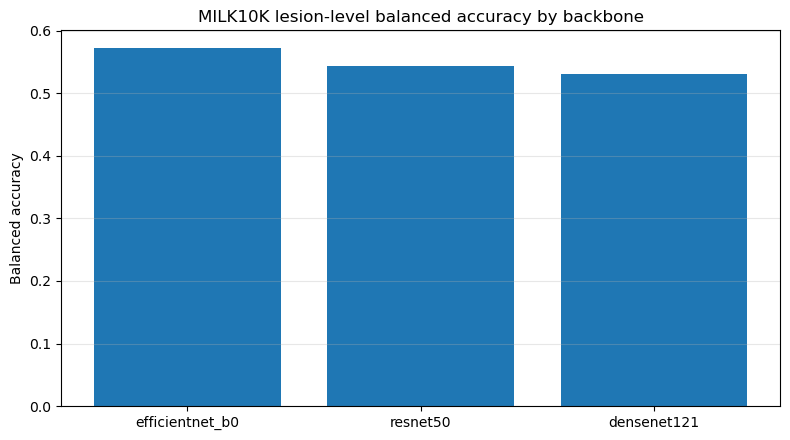

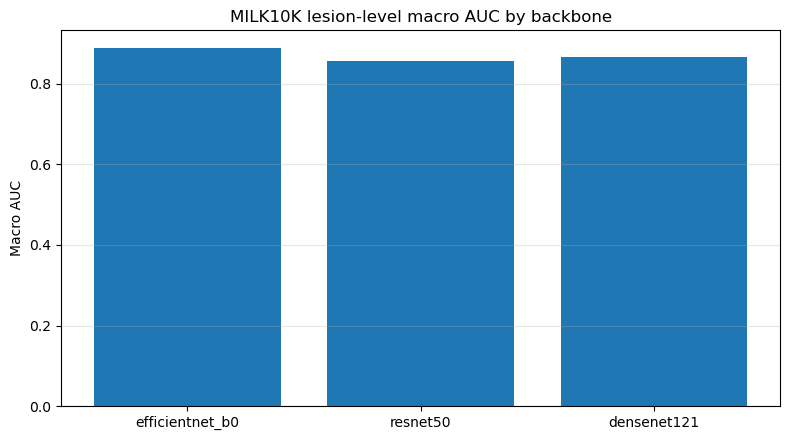

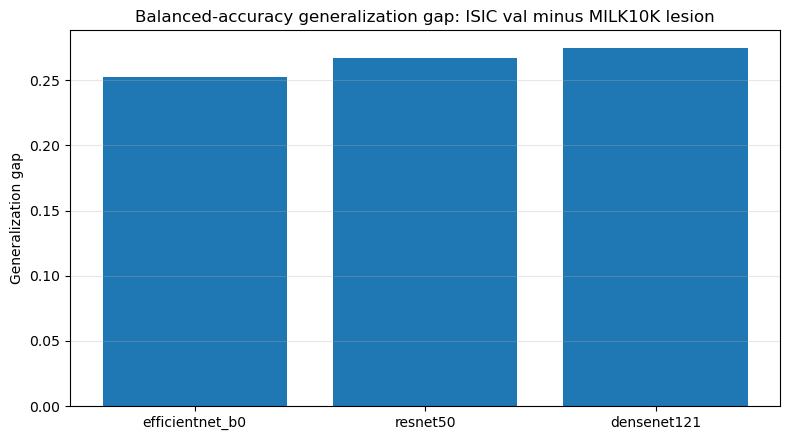

In [26]:
# ============================================================
# PLOTS FOR THE INITIAL THREE-MODEL EXTERNAL COMPARISON
# ============================================================

plot_df = initial_summary_df.copy()

# Lesion BACC
plt.figure(figsize=(8, 4.5))
plt.bar(plot_df["backbone"], plot_df["milk_lesion_bacc"])
plt.title("MILK10K lesion-level balanced accuracy by backbone")
plt.ylabel("Balanced accuracy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        FIG_DIR / ("initial_external_lesion_bacc_smoke.png" if SMOKE_MODE else "initial_external_lesion_bacc_full.png"),
        dpi=200,
        bbox_inches="tight",
    )

plt.show()

# Lesion macro AUC
plt.figure(figsize=(8, 4.5))
plt.bar(plot_df["backbone"], plot_df["milk_lesion_macro_auc"])
plt.title("MILK10K lesion-level macro AUC by backbone")
plt.ylabel("Macro AUC")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        FIG_DIR / ("initial_external_lesion_macro_auc_smoke.png" if SMOKE_MODE else "initial_external_lesion_macro_auc_full.png"),
        dpi=200,
        bbox_inches="tight",
    )

plt.show()

# BACC generalization gap
plt.figure(figsize=(8, 4.5))
plt.bar(plot_df["backbone"], plot_df["bacc_generalization_gap"])
plt.title("Balanced-accuracy generalization gap: ISIC val minus MILK10K lesion")
plt.ylabel("Generalization gap")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        FIG_DIR / ("initial_external_bacc_gap_smoke.png" if SMOKE_MODE else "initial_external_bacc_gap_full.png"),
        dpi=200,
        bbox_inches="tight",
    )

plt.show()


## Review the top lesion-level outputs

This final inspection cell is a small audit of the resulting lesion-level prediction tables.

It is useful for quickly checking:

* predicted labels
* lesion-level probabilities
* whether the saved outputs look tidy and interpretable


In [27]:
# ============================================================
# QUICK AUDIT OF ONE LESION-LEVEL PREDICTION TABLE
# ============================================================

example_lesion_df = initial_results[0]["lesion_pred_df"].copy()

display(
    example_lesion_df[
        ["lesion_id", "true_label", "pred_label"] + probability_columns(CANONICAL_LABELS)
    ].head(10)
)


,lesion_id,true_label,pred_label,prob_AK,prob_BCC,prob_BKL,prob_DF,prob_MEL,prob_NV,prob_SCC,prob_VASC
0,IL_0005081,SCC,MEL,0.029565,0.043076,0.231484,0.008868,0.479987,0.193809,0.008391,0.004820
1,IL_0076383,BKL,NV,0.007402,0.020391,0.041704,0.003504,0.016510,0.901881,0.005608,0.002999
2,IL_0097757,BKL,BKL,0.037216,0.045083,0.314401,0.072609,0.193943,0.218192,0.109369,0.009188
3,IL_0106759,DF,NV,0.002511,0.019110,0.002956,0.404700,0.047682,0.499834,0.020436,0.002771
4,IL_0142779,SCC,BKL,0.413965,0.013919,0.540627,0.003963,0.009132,0.014724,0.002632,0.001039
5,IL_0159004,SCC,MEL,0.109052,0.107992,0.014396,0.009201,0.378071,0.133789,0.237762,0.009738
6,IL_0159486,MEL,BKL,0.071009,0.058529,0.574000,0.005239,0.010080,0.265813,0.009030,0.006300
7,IL_0169358,BKL,BCC,0.023512,0.352231,0.334310,0.004121,0.007803,0.118032,0.154822,0.005168
8,IL_0180498,BCC,AK,0.399339,0.379053,0.110365,0.012294,0.012917,0.056781,0.018426,0.010825
9,IL_0184125,DF,DF,0.001361,0.283827,0.006644,0.500987,0.001919,0.198162,0.003141,0.003960


## Full external evaluation workflow

The smoke-mode results above serve as the pipeline-verification pass for Notebook 06.

That earlier run confirms that the external evaluation workflow operates correctly on a lesion-stratified MILK10K subset, including data loading, label harmonization, lesion-level aggregation, checkpoint loading, metric computation, figure generation, and output saving.

Notebook 06 now proceeds to the full external evaluation workflow.

In this full-session pass, the notebook follows Step A of the planned external-evaluation order:

- evaluate the final cumulative augmentation checkpoint
- run one backbone at a time for HPC practicality
- compare full MILK10K external performance against the corresponding internal ISIC validation reference

The following sections run the full external sessions sequentially, one backbone at a time.


In [28]:

# ============================================================
# RUN CONTROL, FULL EXTERNAL EVALUATION
# ============================================================

SMOKE_MODE = False
INITIAL_EXTERNAL_ONLY = True
BACKBONES_TO_RUN = BACKBONES.copy()

milk_eval_lesions_df = milk_supported_lesions_df.copy()

milk_eval_df = milk_supported_images_df[
    milk_supported_images_df["lesion_id"].isin(milk_eval_lesions_df["lesion_id"])
].copy()

milk_eval_df = milk_eval_df.sort_values(
    ["lesion_id", "image_type", "isic_id"]
).reset_index(drop=True)

milk_eval_dataset = MilkExternalDataset(
    df=milk_eval_df,
    transform=eval_transform,
)

milk_eval_loader = DataLoader(
    milk_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    generator=loader_generator,
)

FULL_WORKFLOW_CONFIG = {
    "notebook": "06_external_evaluation",
    "mode": "full",
    "initial_external_only": INITIAL_EXTERNAL_ONLY,
    "primary_stage": PRIMARY_STAGE,
    "backbones_to_run": BACKBONES_TO_RUN,
    "n_eval_lesions": int(len(milk_eval_lesions_df)),
    "n_eval_images": int(len(milk_eval_df)),
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "seed": EXPERIMENT_SEED,
}

full_workflow_config_path = CONFIG_DIR / "06_full_external_workflow.json"

with open(full_workflow_config_path, "w") as f:
    json.dump(FULL_WORKFLOW_CONFIG, f, indent=2)

print("Full external workflow activated.")
print("SMOKE_MODE:", SMOKE_MODE)
print("INITIAL_EXTERNAL_ONLY:", INITIAL_EXTERNAL_ONLY)
print("BACKBONES_TO_RUN:", BACKBONES_TO_RUN)
print()
print("Saved workflow config to:", full_workflow_config_path)
print("Evaluation lesions:", len(milk_eval_lesions_df))
print("Evaluation images:", len(milk_eval_df))
print()
print("Evaluation lesion class counts:")
print(milk_eval_lesions_df["label"].value_counts().sort_index())


Full external workflow activated.
SMOKE_MODE: False
INITIAL_EXTERNAL_ONLY: True
BACKBONES_TO_RUN: ['resnet50', 'efficientnet_b0', 'densenet121']

Saved workflow config to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/06_external_evaluation/06_full_external_workflow.json
Evaluation lesions: 5137
Evaluation images: 10274

Evaluation lesion class counts:
label
AK       303
BCC     2522
BKL      544
DF        52
MEL      450
NV       746
SCC      473
VASC      47
Name: count, dtype: int64


## Runtime monitoring and execution planning

This section adds lightweight runtime monitoring to Notebook 06.

The goal is to make full external-evaluation sessions easier to manage in both local and HPC environments by surfacing:

- wall-clock start and end times
- live batch progress during inference
- estimated time remaining
- total inference runtime
- total session runtime
- average time per batch
- average time per image

These additions do not change the scientific design of the notebook.

They instrument the existing external-evaluation workflow so that runtime behavior can be observed directly in notebook output and saved into summary tables for future development planning and HPC allocation decisions.


In [29]:
# ============================================================
# RUNTIME MONITORING UTILITIES
# ============================================================

from time import perf_counter
from datetime import datetime

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def now_string():
    # Return a readable wall-clock timestamp
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def format_seconds(seconds):
    # Convert seconds to H:MM:SS or M:SS
    seconds = float(seconds)
    total = int(round(seconds))
    hours, rem = divmod(total, 3600)
    minutes, secs = divmod(rem, 60)

    if hours > 0:
        return f"{hours}:{minutes:02d}:{secs:02d}"
    return f"{minutes}:{secs:02d}"


RUNTIME_LOG = []

print("Runtime monitoring utilities ready.")
print("tqdm available:", tqdm is not None)


Runtime monitoring utilities ready.
tqdm available: True


/home/gsr3qz/.conda/envs/ds6050-skin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# ============================================================
# IMAGE-LEVEL INFERENCE WITH PROGRESS MONITORING
# ============================================================

def run_image_level_inference(model, dataloader, class_labels, device=DEVICE, run_name="external_inference"):
    # Run inference across the active external dataloader
    prob_cols = probability_columns(class_labels)
    rows = []

    total_batches = len(dataloader)
    total_images = len(dataloader.dataset)

    start_stamp = now_string()
    run_start = perf_counter()

    print("=" * 70)
    print(f"Run name: {run_name}")
    print(f"Start time: {start_stamp}")
    print(f"Total images: {total_images}")
    print(f"Total batches: {total_batches}")
    print(f"Batch size: {dataloader.batch_size}")
    print(f"Device: {device}")
    print("=" * 70)

    model.eval()
    seen_images = 0

    batch_iterator = dataloader
    if tqdm is not None:
        batch_iterator = tqdm(
            dataloader,
            total=total_batches,
            desc=run_name,
            unit="batch",
            dynamic_ncols=True,
        )

    with torch.no_grad():
        for batch_idx, batch in enumerate(batch_iterator, start=1):
            # Move one batch to the device and run inference
            x = batch["image"].to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            batch_size = probs.shape[0]
            seen_images += batch_size

            # Save one output row per image
            for i in range(batch_size):
                row = {
                    "lesion_id": batch["lesion_id"][i],
                    "isic_id": batch["isic_id"][i],
                    "image_type": batch["image_type"][i],
                    "image_path": batch["image_path"][i],
                    "milk_label_raw": batch["milk_label_raw"][i],
                    "true_label": batch["label"][i],
                    "true_label_idx": int(batch["label_idx"][i].item()),
                }

                for c, prob_col in enumerate(prob_cols):
                    row[prob_col] = float(probs[i, c])

                rows.append(row)

            # Update elapsed time and ETA
            elapsed = perf_counter() - run_start
            avg_batch_time = elapsed / batch_idx
            remaining_batches = total_batches - batch_idx
            eta_seconds = avg_batch_time * remaining_batches

            if tqdm is not None:
                batch_iterator.set_postfix(
                    images=f"{seen_images}/{total_images}",
                    elapsed=format_seconds(elapsed),
                    eta=format_seconds(max(eta_seconds, 0)),
                    refresh=False,
                )
            else:
                print(
                    f"[{batch_idx:>4d}/{total_batches}] "
                    f"images={seen_images}/{total_images} | "
                    f"elapsed={format_seconds(elapsed)} | "
                    f"eta={format_seconds(max(eta_seconds, 0))}"
                )

    total_elapsed = perf_counter() - run_start
    end_stamp = now_string()

    timing_record = {
        "run_name": run_name,
        "start_time": start_stamp,
        "end_time": end_stamp,
        "n_images": total_images,
        "n_batches": total_batches,
        "elapsed_sec": total_elapsed,
        "elapsed_hms": format_seconds(total_elapsed),
        "sec_per_batch": total_elapsed / max(total_batches, 1),
        "sec_per_image": total_elapsed / max(total_images, 1),
    }

    RUNTIME_LOG.append(timing_record)
    run_image_level_inference.last_timing = timing_record

    print("-" * 70)
    print(f"End time: {end_stamp}")
    print(f"Total inference time: {timing_record['elapsed_hms']} ({total_elapsed:.2f} sec)")
    print(f"Average time per batch: {timing_record['sec_per_batch']:.4f} sec")
    print(f"Average time per image: {timing_record['sec_per_image']:.6f} sec")
    print("-" * 70)

    image_pred_df = pd.DataFrame(rows)
    image_pred_df = add_predicted_labels(image_pred_df, class_labels)
    image_pred_df = image_pred_df.sort_values(
        ["lesion_id", "image_type", "isic_id"]
    ).reset_index(drop=True)

    return image_pred_df


## Full external evaluation session, ResNet-50

This section runs the first full external validation session for Notebook 06.

The smoke-mode results above remain preserved as the pipeline-verification pass.

This session begins Step A of the planned external-evaluation order by evaluating the `phase1_plus_2_plus_3_plus_4` ResNet-50 checkpoint on the full supported MILK10K external evaluation set.

Lesion-level performance is treated as the primary analysis in this session.

This session saves:

- lesion-level predictions
- lesion-level confusion matrices
- lesion-level metric report
- one full external summary row for ResNet-50


In [31]:

# ============================================================
# FULL EXTERNAL SESSION HELPER
# ============================================================

def run_full_external_session(backbone, stage, dataloader, session_label="full"):
    loaded = load_trained_model(backbone=backbone, stage=stage, device=DEVICE)
    model = loaded["model"]
    class_labels = loaded["label_order"]

    image_pred_df = run_image_level_inference(
        model=model,
        dataloader=dataloader,
        class_labels=class_labels,
        device=DEVICE,
        run_name=f"{backbone}_{stage}_{session_label}",
    )

    lesion_pred_df = aggregate_to_lesions(
        image_pred_df=image_pred_df,
        class_labels=class_labels,
    )

    lesion_metrics = compute_classification_metrics(
        pred_df=lesion_pred_df,
        class_labels=class_labels,
    )

    internal_ref = lookup_internal_reference_metrics(
        df=ablat04_df,
        backbone=backbone,
        stage=stage,
    )

    prefix = f"{backbone}_{stage}_{session_label}"

    if SAVE_PREDICTIONS:
        lesion_pred_df.to_csv(PRED_DIR / f"{prefix}_lesion_preds.csv", index=False)

    if SAVE_FIGURES:
        save_confusion_matrix_figures(
            metrics_dict=lesion_metrics,
            class_labels=class_labels,
            fig_dir=FIG_DIR,
            prefix=f"{prefix}_lesion",
        )

    summary_row = {
        "backbone": backbone,
        "stage": stage,
        "checkpoint_path": str(loaded["checkpoint_path"]),
        "n_images": len(image_pred_df),
        "n_lesions": len(lesion_pred_df),
        "milk_lesion_macro_auc": lesion_metrics["macro_auc"],
        "milk_lesion_bacc": lesion_metrics["balanced_accuracy"],
        "isic_val_macro_auc": internal_ref["isic_val_macro_auc"],
        "isic_val_bacc": internal_ref["isic_val_bacc"],
    }

    summary_row["auc_generalization_gap"] = (
        summary_row["isic_val_macro_auc"] - summary_row["milk_lesion_macro_auc"]
        if pd.notna(summary_row["isic_val_macro_auc"]) else np.nan
    )
    summary_row["bacc_generalization_gap"] = (
        summary_row["isic_val_bacc"] - summary_row["milk_lesion_bacc"]
        if pd.notna(summary_row["isic_val_bacc"]) else np.nan
    )

    runtime_info = getattr(run_image_level_inference, "last_timing", None)
    if runtime_info is not None:
        summary_row["inference_elapsed_hms"] = runtime_info["elapsed_hms"]

    if SAVE_REPORTS:
        metric_report = {
            "backbone": backbone,
            "stage": stage,
            "checkpoint_path": str(loaded["checkpoint_path"]),
            "n_images": len(image_pred_df),
            "n_lesions": len(lesion_pred_df),
            "lesion_metrics": {
                "macro_auc": lesion_metrics["macro_auc"],
                "balanced_accuracy": lesion_metrics["balanced_accuracy"],
                "classification_report": lesion_metrics["classification_report"],
            },
            "internal_reference": internal_ref,
            "generalization_gap": {
                "macro_auc_gap": summary_row["auc_generalization_gap"],
                "balanced_accuracy_gap": summary_row["bacc_generalization_gap"],
            },
            "runtime": {
                "inference_elapsed_hms": summary_row.get("inference_elapsed_hms", None),
            },
        }

        with open(REPORT_DIR / f"{prefix}_metric_report.json", "w") as f:
            json.dump(metric_report, f, indent=2)

    return {
        "lesion_pred_df": lesion_pred_df,
        "summary_row": summary_row,
    }


ACTIVE_BACKBONE = "resnet50"
ACTIVE_STAGE = PRIMARY_STAGE
SESSION_LABEL = "full"

print("=" * 70)
print(f"Running FULL external evaluation for {ACTIVE_BACKBONE} | {ACTIVE_STAGE}")
print("=" * 70)

session_result = run_full_external_session(
    backbone=ACTIVE_BACKBONE,
    stage=ACTIVE_STAGE,
    dataloader=milk_eval_loader,
    session_label=SESSION_LABEL,
)

session_summary_df = pd.DataFrame([session_result["summary_row"]]).copy()

session_summary_path = METRIC_DIR / "06_full_external_session_resnet50.csv"
session_summary_df.to_csv(session_summary_path, index=False)

print()
print("Saved session summary to:", session_summary_path)
print()

display_cols = [
    "backbone",
    "stage",
    "n_images",
    "n_lesions",
    "milk_lesion_macro_auc",
    "milk_lesion_bacc",
    "isic_val_macro_auc",
    "isic_val_bacc",
    "auc_generalization_gap",
    "bacc_generalization_gap",
]

if "inference_elapsed_hms" in session_summary_df.columns:
    display_cols.append("inference_elapsed_hms")

display(session_summary_df[display_cols])


Running FULL external evaluation for resnet50 | phase1_plus_2_plus_3_plus_4


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


Run name: resnet50_phase1_plus_2_plus_3_plus_4_full
Start time: 2026-04-23 14:37:38
Total images: 10274
Total batches: 322
Batch size: 32
Device: cuda


resnet50_phase1_plus_2_plus_3_plus_4_full: 100%|██████████| 322/322 [02:16<00:00,  2.35batch/s, elapsed=2:17, eta=0:00, images=10274/10274]


----------------------------------------------------------------------
End time: 2026-04-23 14:39:55
Total inference time: 2:17 (136.92 sec)
Average time per batch: 0.4252 sec
Average time per image: 0.013327 sec
----------------------------------------------------------------------

Saved session summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_full_external_session_resnet50.csv



,backbone,stage,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,auc_generalization_gap,bacc_generalization_gap,inference_elapsed_hms
0,resnet50,phase1_plus_2_plus_3_plus_4,10274,5137,0.854323,0.526496,0.967936,0.810875,0.113613,0.284379,2:17


## Full external evaluation session, EfficientNet-B0

This section runs the second full external validation session for Notebook 06.

The smoke-mode results and the completed full ResNet-50 session remain preserved above.

This session continues Step A of the planned external-evaluation order by evaluating the `phase1_plus_2_plus_3_plus_4` EfficientNet-B0 checkpoint on the full supported MILK10K external evaluation set.

Lesion-level performance is treated as the primary analysis in this session.

This session saves:

- lesion-level predictions
- lesion-level confusion matrices
- lesion-level metric report
- one full external summary row for EfficientNet-B0


In [32]:

# ============================================================
# FULL EXTERNAL SESSION RUN, EFFICIENTNET-B0
# ============================================================

ACTIVE_BACKBONE = "efficientnet_b0"
ACTIVE_STAGE = PRIMARY_STAGE
SESSION_LABEL = "full"

print("=" * 70)
print(f"Running FULL external evaluation for {ACTIVE_BACKBONE} | {ACTIVE_STAGE}")
print("=" * 70)

session_result = run_full_external_session(
    backbone=ACTIVE_BACKBONE,
    stage=ACTIVE_STAGE,
    dataloader=milk_eval_loader,
    session_label=SESSION_LABEL,
)

session_summary_df = pd.DataFrame([session_result["summary_row"]]).copy()

session_summary_path = METRIC_DIR / "06_full_external_session_efficientnet_b0.csv"
session_summary_df.to_csv(session_summary_path, index=False)

print()
print("Saved session summary to:", session_summary_path)
print()

display_cols = [
    "backbone",
    "stage",
    "n_images",
    "n_lesions",
    "milk_lesion_macro_auc",
    "milk_lesion_bacc",
    "isic_val_macro_auc",
    "isic_val_bacc",
    "auc_generalization_gap",
    "bacc_generalization_gap",
]

if "inference_elapsed_hms" in session_summary_df.columns:
    display_cols.append("inference_elapsed_hms")

display(session_summary_df[display_cols])


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


Running FULL external evaluation for efficientnet_b0 | phase1_plus_2_plus_3_plus_4
Run name: efficientnet_b0_phase1_plus_2_plus_3_plus_4_full
Start time: 2026-04-23 14:39:56
Total images: 10274
Total batches: 322
Batch size: 32
Device: cuda


efficientnet_b0_phase1_plus_2_plus_3_plus_4_full: 100%|██████████| 322/322 [00:43<00:00,  7.47batch/s, elapsed=0:43, eta=0:00, images=10274/10274]


----------------------------------------------------------------------
End time: 2026-04-23 14:40:39
Total inference time: 0:43 (43.13 sec)
Average time per batch: 0.1339 sec
Average time per image: 0.004198 sec
----------------------------------------------------------------------

Saved session summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_full_external_session_efficientnet_b0.csv



,backbone,stage,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,auc_generalization_gap,bacc_generalization_gap,inference_elapsed_hms
0,efficientnet_b0,phase1_plus_2_plus_3_plus_4,10274,5137,0.879907,0.568472,0.972342,0.824013,0.092435,0.255542,0:43


## Full external evaluation session, DenseNet-121

This section runs the third full external validation session for Notebook 06.

The smoke-mode results and the completed full ResNet-50 and EfficientNet-B0 sessions remain preserved above.

This session completes Step A of the planned external-evaluation order by evaluating the `phase1_plus_2_plus_3_plus_4` DenseNet-121 checkpoint on the full supported MILK10K external evaluation set.

Lesion-level performance is treated as the primary analysis in this session.

This session saves:

- lesion-level predictions
- lesion-level confusion matrices
- lesion-level metric report
- one full external summary row for DenseNet-121


In [33]:

# ============================================================
# FULL EXTERNAL SESSION RUN, DENSENET-121
# ============================================================

ACTIVE_BACKBONE = "densenet121"
ACTIVE_STAGE = PRIMARY_STAGE
SESSION_LABEL = "full"

print("=" * 70)
print(f"Running FULL external evaluation for {ACTIVE_BACKBONE} | {ACTIVE_STAGE}")
print("=" * 70)

session_result = run_full_external_session(
    backbone=ACTIVE_BACKBONE,
    stage=ACTIVE_STAGE,
    dataloader=milk_eval_loader,
    session_label=SESSION_LABEL,
)

session_summary_df = pd.DataFrame([session_result["summary_row"]]).copy()

session_summary_path = METRIC_DIR / "06_full_external_session_densenet121.csv"
session_summary_df.to_csv(session_summary_path, index=False)

print()
print("Saved session summary to:", session_summary_path)
print()

display_cols = [
    "backbone",
    "stage",
    "n_images",
    "n_lesions",
    "milk_lesion_macro_auc",
    "milk_lesion_bacc",
    "isic_val_macro_auc",
    "isic_val_bacc",
    "auc_generalization_gap",
    "bacc_generalization_gap",
]

if "inference_elapsed_hms" in session_summary_df.columns:
    display_cols.append("inference_elapsed_hms")

display(session_summary_df[display_cols])


Running FULL external evaluation for densenet121 | phase1_plus_2_plus_3_plus_4


/tmp/ipykernel_110098/2930717749.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_obj = torch.load(ckpt_path, map_location=device)


Run name: densenet121_phase1_plus_2_plus_3_plus_4_full
Start time: 2026-04-23 14:40:40
Total images: 10274
Total batches: 322
Batch size: 32
Device: cuda


densenet121_phase1_plus_2_plus_3_plus_4_full: 100%|██████████| 322/322 [00:44<00:00,  7.19batch/s, elapsed=0:45, eta=0:00, images=10274/10274]


----------------------------------------------------------------------
End time: 2026-04-23 14:41:25
Total inference time: 0:45 (44.76 sec)
Average time per batch: 0.1390 sec
Average time per image: 0.004356 sec
----------------------------------------------------------------------

Saved session summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_full_external_session_densenet121.csv



,backbone,stage,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,auc_generalization_gap,bacc_generalization_gap,inference_elapsed_hms
0,densenet121,phase1_plus_2_plus_3_plus_4,10274,5137,0.852172,0.560378,0.964059,0.805763,0.111886,0.245385,0:45


## Full Step A comparison across completed backbone sessions

After the three full backbone sessions complete, this section combines their saved summary files into one full external comparison table.

The comparison focuses on lesion-level external performance and the corresponding ISIC-to-MILK10K generalization gap for each backbone at the `phase1_plus_2_plus_3_plus_4` stage.


In [34]:

# ============================================================
# FULL STEP A COMPARISON TABLE
# ============================================================

FULL_STEP_A_SUMMARY_PATHS = [
    METRIC_DIR / "06_full_external_session_resnet50.csv",
    METRIC_DIR / "06_full_external_session_efficientnet_b0.csv",
    METRIC_DIR / "06_full_external_session_densenet121.csv",
]

available_summary_paths = [p for p in FULL_STEP_A_SUMMARY_PATHS if p.exists()]

if not available_summary_paths:
    print("No full-session summary files were found yet.")
else:
    full_step_a_df = pd.concat(
        [pd.read_csv(p) for p in available_summary_paths],
        axis=0,
        ignore_index=True,
    )

    full_step_a_df = full_step_a_df.sort_values(
        ["milk_lesion_bacc", "milk_lesion_macro_auc"],
        ascending=False,
    ).reset_index(drop=True)

    full_step_a_summary_path = METRIC_DIR / "06_full_step_a_comparison.csv"
    full_step_a_df.to_csv(full_step_a_summary_path, index=False)

    print("Saved full Step A comparison to:", full_step_a_summary_path)
    print()

    display_cols = [
        "backbone",
        "stage",
        "n_images",
        "n_lesions",
        "milk_lesion_macro_auc",
        "milk_lesion_bacc",
        "isic_val_macro_auc",
        "isic_val_bacc",
        "auc_generalization_gap",
        "bacc_generalization_gap",
    ]

    if "inference_elapsed_hms" in full_step_a_df.columns:
        display_cols.append("inference_elapsed_hms")

    display(full_step_a_df[display_cols])


Saved full Step A comparison to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/06_full_step_a_comparison.csv



,backbone,stage,n_images,n_lesions,milk_lesion_macro_auc,milk_lesion_bacc,isic_val_macro_auc,isic_val_bacc,auc_generalization_gap,bacc_generalization_gap,inference_elapsed_hms
0,efficientnet_b0,phase1_plus_2_plus_3_plus_4,10274,5137,0.879907,0.568472,0.972342,0.824013,0.092435,0.255542,0:43
1,densenet121,phase1_plus_2_plus_3_plus_4,10274,5137,0.852172,0.560378,0.964059,0.805763,0.111886,0.245385,0:45
2,resnet50,phase1_plus_2_plus_3_plus_4,10274,5137,0.854323,0.526496,0.967936,0.810875,0.113613,0.284379,2:17
